# Selfie to Anime Project
## Code 0. Import Library

In [2]:
# !pip install Pillow --upgrade

In [2]:

import torch
print(torch.__version__)
print(torch.version.cuda)        # None이면 CUDA 미탑재 버전
print(torch.cuda.is_available()) # False면 CUDA 사용 불가


2.7.1+cu118
11.8
True


In [2]:
print("CUDA 사용 가능 여부:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("사용 중인 GPU 이름:", torch.cuda.get_device_name(0))
    print("CUDA 디바이스 수:", torch.cuda.device_count())
    print("현재 디바이스 번호:", torch.cuda.current_device())

CUDA 사용 가능 여부: True
사용 중인 GPU 이름: NVIDIA GeForce RTX 2060
CUDA 디바이스 수: 1
현재 디바이스 번호: 0


In [3]:
import torch

print("🌟 PyTorch 버전:", torch.__version__)
print("🧠 CUDA 버전:", torch.version.cuda)
print("⚡ CUDA 사용 가능?:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("🚀 GPU 이름:", torch.cuda.get_device_name(0))
else:
    print("❌ CUDA 사용 불가 (CPU 모드로 동작 중)")

🌟 PyTorch 버전: 2.7.1+cu118
🧠 CUDA 버전: 11.8
⚡ CUDA 사용 가능?: True
🚀 GPU 이름: NVIDIA GeForce RTX 2060


In [7]:
import glob
import random
import os

from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import sys
import torch.nn as nn
import torch.nn.functional as F
import torch

import os
import numpy as np
import math
import itertools
import datetime
import time

from torchvision.utils import save_image, make_grid
from torchvision import datasets
from torch.autograd import Variable

## Code 1. Dataset

In [8]:
def to_rgb(image):
    rgb_image = Image.new("RGB", image.size)
    rgb_image.paste(image)
    return rgb_image

In [9]:
class ImageDataset(Dataset):
    def __init__(self, root, transforms_=None, unaligned=False, mode="train"):
        self.transform = transforms.Compose(transforms_)
        self.unaligned = unaligned
        # train 모드일 때는 trainA, trainB에 있는 디렉토리에서 이미지를 불러옵니다. 
        if mode=="train":
            # glob 함수로 trainA 디렉토리의 이미지의 목록을 불러옵니다. 
            self.files_A = sorted(glob.glob(os.path.join(root, "trainA") + "/*.*"))
            self.files_B = sorted(glob.glob(os.path.join(root, "trainB") + "/*.*"))
        else:
            self.files_A = sorted(glob.glob(os.path.join(root, "testA") + "/*.*"))
            self.files_B = sorted(glob.glob(os.path.join(root, "testB") + "/*.*"))

    def __getitem__(self, index):
        # index값으로 이미지의목록 중 이미지 하나를 불러옵니다. 
        image_A = Image.open(self.files_A[index % len(self.files_A)])
        # unaligned 변수로 학습할 Pair를 랜덤으로 고릅니다.  
        if self.unaligned:
            image_B = Image.open(self.files_B[random.randint(0, len(self.files_B) - 1)])
        else:
            image_B = Image.open(self.files_B[index % len(self.files_B)])

        # Convert grayscale images to rgb
        if image_A.mode != "RGB":
            image_A = to_rgb(image_A)
        if image_B.mode != "RGB":
            image_B = to_rgb(image_B)

        item_A = self.transform(image_A)
        item_B = self.transform(image_B)
        return {"A": item_A, "B": item_B}

    def __len__(self):
        return max(len(self.files_A), len(self.files_B))

## Code 2. Generator & Discriminator



In [10]:
def weights_init_normal(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        torch.nn.init.normal_(m.weight.data, 0.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            torch.nn.init.constant_(m.bias.data, 0.0)
    elif classname.find("BatchNorm2d") != -1:
        torch.nn.init.normal_(m.weight.data, 1.0, 0.02)
        torch.nn.init.constant_(m.bias.data, 0.0)

In [11]:
class ResidualBlock(nn.Module):
    def __init__(self, in_features):
        super(ResidualBlock, self).__init__()

        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features),
        )

    def forward(self, x):
        return x + self.block(x)

In [12]:
class GeneratorResNet(nn.Module):
    def __init__(self, input_shape, num_residual_blocks):
        super(GeneratorResNet, self).__init__()

        channels = input_shape[0]

        # Initial convolution block
        out_features = 64
        model = [
            nn.ReflectionPad2d(channels),
            nn.Conv2d(channels, out_features, 7),
            nn.InstanceNorm2d(out_features),
            nn.ReLU(inplace=True),
        ]
        in_features = out_features

        # Downsampling
        for _ in range(2):
            out_features *= 2
            model += [
                nn.Conv2d(in_features, out_features, 3, stride=2, padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True),
            ]
            in_features = out_features

        # Residual blocks
        for _ in range(num_residual_blocks):
            model += [ResidualBlock(out_features)]

        # Upsampling
        for _ in range(2):
            out_features //= 2
            model += [
                nn.Upsample(scale_factor=2),
                nn.Conv2d(in_features, out_features, 3, stride=1, padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True),
            ]
            in_features = out_features

        # Output layer
        model += [nn.ReflectionPad2d(channels), nn.Conv2d(out_features, channels, 7), nn.Tanh()]

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)

In [13]:
class Discriminator(nn.Module):
    def __init__(self, input_shape):
        super(Discriminator, self).__init__()

        channels, height, width = input_shape

        # Calculate output shape of image discriminator (PatchGAN)
        self.output_shape = (1, height // 2 ** 4, width // 2 ** 4)

        def discriminator_block(in_filters, out_filters, normalize=True):
            """Returns downsampling layers of each discriminator block"""
            layers = [nn.Conv2d(in_filters, out_filters, 4, stride=2, padding=1)]
            if normalize:
                layers.append(nn.InstanceNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *discriminator_block(channels, 64, normalize=False),
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            *discriminator_block(256, 512),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(512, 1, 4, padding=1)
        )

    def forward(self, img):
        return self.model(img)

## Code 3. Training

In [14]:
# 수정된 부분
dataset_name = "selfie2anime3"
# dataset_path = "/kaggle/input/selfie2anime"

channels = 3
img_height = 256
img_width = 256
n_residual_blocks=9
lr=0.0002
b1=0.5
b2=0.999
n_epochs=200
init_epoch=0
decay_epoch=100
lambda_cyc=10.0
lambda_id=5.0
n_cpu=8
batch_size=1
sample_interval=100
checkpoint_interval=5

In [15]:
# Create sample and checkpoint directories
os.makedirs("images/%s" % dataset_name, exist_ok=True)
os.makedirs("saved_models/%s" % dataset_name, exist_ok=True)

In [16]:
# Losses
criterion_GAN = torch.nn.MSELoss()
criterion_cycle = torch.nn.L1Loss()
criterion_identity = torch.nn.L1Loss()

In [17]:
input_shape = (channels, img_height, img_width)

# Initialize generator and discriminator
G_AB = GeneratorResNet(input_shape, n_residual_blocks)
G_BA = GeneratorResNet(input_shape, n_residual_blocks)
D_A = Discriminator(input_shape)
D_B = Discriminator(input_shape)

In [18]:
cuda = torch.cuda.is_available()
if cuda:
    G_AB = G_AB.cuda()
    G_BA = G_BA.cuda()
    D_A = D_A.cuda()
    D_B = D_B.cuda()
    criterion_GAN.cuda()
    criterion_cycle.cuda()
    criterion_identity.cuda()

In [19]:
# Initialize weights
G_AB.apply(weights_init_normal)
G_BA.apply(weights_init_normal)
D_A.apply(weights_init_normal)
D_B.apply(weights_init_normal)

Discriminator(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): InstanceNorm2d(512, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): ZeroPad2d((1, 0, 1, 0))
    (12): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
  )
)

In [20]:
# Optimizers
optimizer_G = torch.optim.Adam(
    itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=lr, betas=(b1, b2)
)
optimizer_D_A = torch.optim.Adam(D_A.parameters(), lr=lr, betas=(b1, b2))
optimizer_D_B = torch.optim.Adam(D_B.parameters(), lr=lr, betas=(b1, b2))

In [21]:
class LambdaLR:
    def __init__(self, n_epochs, offset, decay_start_epoch):
        assert (n_epochs - decay_start_epoch) > 0, "Decay must start before the training session ends!"
        self.n_epochs = n_epochs
        self.offset = offset
        self.decay_start_epoch = decay_start_epoch

    def step(self, epoch):
        return 1.0 - max(0, epoch + self.offset - self.decay_start_epoch) / (self.n_epochs - self.decay_start_epoch)

In [22]:
# Learning rate update schedulers
lr_scheduler_G = torch.optim.lr_scheduler.LambdaLR(
    optimizer_G, lr_lambda=LambdaLR(n_epochs, init_epoch, decay_epoch).step
)
lr_scheduler_D_A = torch.optim.lr_scheduler.LambdaLR(
    optimizer_D_A, lr_lambda=LambdaLR(n_epochs, init_epoch, decay_epoch).step
)
lr_scheduler_D_B = torch.optim.lr_scheduler.LambdaLR(
    optimizer_D_B, lr_lambda=LambdaLR(n_epochs, init_epoch, decay_epoch).step
)

In [23]:
cuda = torch.cuda.is_available()
Tensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor

Tensor = torch.cuda.FloatTensor if cuda else torch.Tensor


In [24]:
class ReplayBuffer:
    def __init__(self, max_size=50):
        assert max_size > 0, "Empty buffer or trying to create a black hole. Be careful."
        self.max_size = max_size
        self.data = []

    def push_and_pop(self, data):
        to_return = []
        for element in data.data:
            element = torch.unsqueeze(element, 0)
            if len(self.data) < self.max_size:
                self.data.append(element)
                to_return.append(element)
            else:
                if random.uniform(0, 1) > 0.5:
                    i = random.randint(0, self.max_size - 1)
                    to_return.append(self.data[i].clone())
                    self.data[i] = element
                else:
                    to_return.append(element)
        return Variable(torch.cat(to_return))

In [25]:
# Buffers of previously generated samples
fake_A_buffer = ReplayBuffer()
fake_B_buffer = ReplayBuffer()

In [26]:
# Image transformations
transforms_ = [
    transforms.Resize(int(img_height * 1.12), Image.BICUBIC),
    transforms.RandomCrop((img_height, img_width)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
]

In [27]:
# 중간 확인 작업


print(dataset_name)
import os
print("Current working directory:", os.getcwd())
import os
print(os.listdir("./dataset"))

print(os.listdir("./"))


selfie2anime3
Current working directory: d:\AI\pytorchpj_250712_v2
['testA', 'testB', 'trainA', 'trainB']
['dataset', 'images', 'saved_models', 'selfie2anime-pr_v2.ipynb', 'selfie2anime-pr_v3.ipynb']


In [28]:
import multiprocessing # 추가함

# CPU 코어 수를 기준으로 최대 4개까지만 사용
n_cpu = min(4, multiprocessing.cpu_count()) # 추가함

# 이후 DataLoader에서 그대로 사용
dataloader = DataLoader(
    ImageDataset("./dataset", transforms_=transforms_, unaligned=True),
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,  # 여기서 적용됨
)

val_dataloader = DataLoader(
    ImageDataset("./dataset", transforms_=transforms_, unaligned=True, mode="test"),
    batch_size=5,
    shuffle=True,
    num_workers=0,
)


In [29]:
def sample_images(batches_done):
    """Saves a generated sample from the test set"""
    imgs = next(iter(val_dataloader))
    G_AB.eval()
    G_BA.eval()
    real_A = Variable(imgs["A"].type(Tensor))
    fake_B = G_AB(real_A)
    real_B = Variable(imgs["B"].type(Tensor))
    fake_A = G_BA(real_B)

    # Arange images along x-axis
    real_A = make_grid(real_A, nrow=5, normalize=True)
    real_B = make_grid(real_B, nrow=5, normalize=True)
    fake_A = make_grid(fake_A, nrow=5, normalize=True)
    fake_B = make_grid(fake_B, nrow=5, normalize=True)
    
    # Arange images along y-axis
    image_grid = torch.cat((real_A, fake_B, real_B, fake_A), 1)
    save_image(image_grid, "images/%s/%s.png" % (dataset_name, batches_done), normalize=False)

In [30]:
from torch.amp import GradScaler  # ← 변경된 위치에서 가져오기
scaler = GradScaler(device="cuda")  # ← device 명시

# 모델1: 쿠다를 AMD 그래픽카드로 돌렸을 때 모델

epoch을 수동으로 30 까지만 , 거의 7~80분 걸림

In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [29]:
import torch
from torch.autograd import Variable
from torch.amp import GradScaler
from torch.cuda.amp import autocast # <-- 다시 이 임포트로 변경합니다.

import numpy as np
import datetime
import time
import sys

# ✅ [수정] 학습 epoch 수 변경 (200 → 30)
n_epochs = 30  # 전체 학습 epoch 수를 30으로 조정하여 학습 시간을 단축함

# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# cuDNN 최적화
torch.backends.cudnn.benchmark = True

# 모델을 device로 이동
G_AB = G_AB.to(device)
G_BA = G_BA.to(device)
D_A = D_A.to(device)
D_B = D_B.to(device)

# 손실 함수도 device로 이동
criterion_GAN = criterion_GAN.to(device)
criterion_cycle = criterion_cycle.to(device)
criterion_identity = criterion_identity.to(device)

# Mixed Precision Training을 위한 준비
scaler = GradScaler(device="cuda")

# 체크포인트 및 이미지 저장 설정
checkpoint_interval = 10
sample_interval = 100
init_epoch = 0

prev_time = time.time()
for epoch in range(init_epoch, n_epochs):
    for i, batch in enumerate(dataloader):

        # 모델 입력 준비 (device로 이동)
        real_A = batch["A"].to(device)
        real_B = batch["B"].to(device)

        # 진짜/가짜 판별 라벨 생성
        valid = torch.ones((real_A.size(0), *D_A.output_shape), device=device, dtype=torch.float32, requires_grad=False)
        fake = torch.zeros((real_A.size(0), *D_A.output_shape), device=device, dtype=torch.float32, requires_grad=False)

        # 생성자 학습
        G_AB.train()
        G_BA.train()
        optimizer_G.zero_grad()

        # Mixed Precision: autocast()를 인자 없이 사용하거나,
        #                   dtype=torch.float16 (또는 torch.bfloat16)과 같이 사용합니다.
        #                   여기서는 가장 기본적인 인자 없는 형태로 변경합니다.
        with autocast(): # <-- 이 부분을 이렇게 변경합니다. (인자 제거)
            # 아이덴티티 손실
            loss_id_A = criterion_identity(G_BA(real_A), real_A)
            loss_id_B = criterion_identity(G_AB(real_B), real_B)
            loss_identity = (loss_id_A + loss_id_B) / 2

            # GAN 손실
            fake_B = G_AB(real_A)
            loss_GAN_AB = criterion_GAN(D_B(fake_B), valid)
            fake_A = G_BA(real_B)
            loss_GAN_BA = criterion_GAN(D_A(fake_A), valid)
            loss_GAN = (loss_GAN_AB + loss_GAN_BA) / 2

            # 사이클 일관성 손실
            recov_A = G_BA(fake_B)
            loss_cycle_A = criterion_cycle(recov_A, real_A)
            recov_B = G_AB(fake_A)
            loss_cycle_B = criterion_cycle(recov_B, real_B)
            loss_cycle = (loss_cycle_A + loss_cycle_B) / 2

            # 전체 생성자 손실
            loss_G = loss_GAN + lambda_cyc * loss_cycle + lambda_id * loss_identity

        scaler.scale(loss_G).backward()
        scaler.step(optimizer_G)
        scaler.update()

        # 판별자 A 학습
        optimizer_D_A.zero_grad()
        with autocast(): # <-- 이 부분도 이렇게 변경합니다. (인자 제거)
            loss_real = criterion_GAN(D_A(real_A), valid)
            fake_A_ = fake_A_buffer.push_and_pop(fake_A)
            loss_fake = criterion_GAN(D_A(fake_A_.detach()), fake)
            loss_D_A = (loss_real + loss_fake) / 2

        scaler.scale(loss_D_A).backward()
        scaler.step(optimizer_D_A)
        scaler.update()

        # 판별자 B 학습
        optimizer_D_B.zero_grad()
        with autocast(): # <-- 이 부분도 이렇게 변경합니다. (인자 제거)
            loss_real = criterion_GAN(D_B(real_B), valid)
            fake_B_ = fake_B_buffer.push_and_pop(fake_B)
            loss_fake = criterion_GAN(D_B(fake_B_.detach()), fake)
            loss_D_B = (loss_real + loss_fake) / 2

        scaler.scale(loss_D_B).backward()
        scaler.step(optimizer_D_B)
        scaler.update()

        # 전체 판별자 손실
        loss_D = (loss_D_A + loss_D_B) / 2

        # 남은 시간 계산
        batches_done = epoch * len(dataloader) + i
        batches_left = n_epochs * len(dataloader) - batches_done
        time_left = datetime.timedelta(seconds=batches_left * (time.time() - prev_time))
        prev_time = time.time()

        # 로그 출력
        sys.stdout.write(
            "\r[Epoch %d/%d] [Batch %d/%d] [D loss: %.4f] [G loss: %.4f, adv: %.4f, cycle: %.4f, identity: %.4f] ETA: %s"
            % (
                epoch,
                n_epochs,
                i,
                len(dataloader),
                loss_D.item(),
                loss_G.item(),
                loss_GAN.item(),
                loss_cycle.item(),
                loss_identity.item(),
                time_left,
            )
        )
        sys.stdout.flush()

        # 이미지 저장
        if batches_done % sample_interval == 0:
            sample_images(batches_done)

    # 학습률 스케줄러 업데이트
    lr_scheduler_G.step()
    lr_scheduler_D_A.step()
    lr_scheduler_D_B.step()

    # 체크포인트 저장
    if checkpoint_interval != -1 and epoch % checkpoint_interval == 0:
        torch.save(G_AB.state_dict(), f"saved_models/{dataset_name}/G_AB_{epoch}.pth")
        torch.save(G_BA.state_dict(), f"saved_models/{dataset_name}/G_BA_{epoch}.pth")
        torch.save(D_A.state_dict(), f"saved_models/{dataset_name}/D_A_{epoch}.pth")
        torch.save(D_B.state_dict(), f"saved_models/{dataset_name}/D_B_{epoch}.pth")

cuda


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_3640\1301112661.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # <-- 이 부분을 이렇게 변경합니다. (인자 제거)


[Epoch 0/30] [Batch 0/400] [D loss: 1.8321] [G loss: 11.9064, adv: 2.5508, cycle: 0.6243, identity: 0.6224] ETA: 5:55:11.854362

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_3640\1301112661.py:89: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # <-- 이 부분도 이렇게 변경합니다. (인자 제거)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_3640\1301112661.py:101: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # <-- 이 부분도 이렇게 변경합니다. (인자 제거)


[Epoch 29/30] [Batch 399/400] [D loss: 0.1562] [G loss: 2.7975, adv: 0.4621, cycle: 0.1671, identity: 0.1329] ETA: 0:00:00.298536

# 모델2: 쿠다를 Nvidia rtx2060 으로 돌린 모델

epoch을 50으로 늘리고, 위 모델과 비교하기 위해 새로운 폴더 dataset_n 결과물을 생성함
20분 걸림

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.current_device())
print(torch.cuda.get_device_name(0)) # 첫 번째 GPU 이름 확인

True
1
0
NVIDIA GeForce RTX 2060


In [6]:
import torch
from torch.autograd import Variable
from torch.amp import GradScaler
from torch.cuda.amp import autocast
import numpy as np
import datetime
import time
import sys

# 학습 epoch 수 설정 (50으로 조정)
n_epochs = 50

# device를 명시적으로 "cuda"로 설정
device = torch.device("cuda") 

# 이 부분이 콘솔에 출력되어 CUDA 사용 여부를 알려줍니다.
print(f"Using device: {device}")

# 더 확실히 확인하려면 아래 라인들도 추가해보세요.
print(f"CUDA is available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU name: {torch.cuda.get_device_name(0)}")

# 나머지 학습 관련 코드는 여기에 이어집니다.
# ...

Using device: cuda
CUDA is available: True
Number of GPUs: 1
Current GPU name: NVIDIA GeForce RTX 2060


In [5]:
import torch
import torch.nn as nn # nn 모듈 임포트 추가
from torch.autograd import Variable
from torch.amp import GradScaler
from torch.cuda.amp import autocast # Mixed Precision Training을 위해 필요

import numpy as np
import datetime
import time
import sys
import os # 폴더 생성 및 관리를 위해 필요
import itertools # 옵티마이저 정의를 위해 필요

# 데이터 로딩 및 이미지 저장을 위한 필수 라이브러리
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.utils as vutils # 이미지 저장을 위해 vutils 임포트
from PIL import Image # 이미지 처리를 위해 PIL 라이브러리 필요

# --- **[필수 정의] CycleGAN 학습에 필요한 클래스와 함수들** ---
# (이 부분들은 사용자님의 코드에서 외부 파일에 정의되어 있었거나, 이전에 생략된 부분으로 보입니다.
#  코드 실행을 위해 여기에 포함합니다. 실제 모델 아키텍처는 CycleGAN 논문 등을 참고하여 구현되어야 합니다.)

# 1. ImageDataset 클래스 (데이터 로딩을 위해 필요)
class ImageDataset(Dataset):
    def __init__(self, root, transform_=None, mode='train'):
        self.transform = transforms.Compose(transform_)
        # D:/AI/pytorchpj/dataset/trainA, D:/AI/pytorchpj/dataset/trainB 등을 찾음
        self.files_A = sorted(os.listdir(os.path.join(root, f'{mode}A')))
        self.files_B = sorted(os.listdir(os.path.join(root, f'{mode}B')))
        self.root = root
        self.mode = mode

    def __getitem__(self, index):
        img_A = Image.open(os.path.join(self.root, f'{self.mode}A', self.files_A[index % len(self.files_A)]))
        img_B = Image.open(os.path.join(self.root, f'{self.mode}B', self.files_B[index % len(self.files_B)]))

        if img_A.mode != 'RGB':
            img_A = img_A.convert('RGB')
        if img_B.mode != 'RGB':
            img_B = img_B.convert('RGB')
            
        item_A = self.transform(img_A)
        item_B = self.transform(img_B)
        return {"A": item_A, "B": item_B}

    def __len__(self):
        return max(len(self.files_A), len(self.files_B))

# 2. ReplayBuffer 클래스 (가짜 이미지 저장을 위해 필요)
class ReplayBuffer:
    def __init__(self, max_size=50):
        assert (max_size > 0)
        self.max_size = max_size
        self.data = []

    def push_and_pop(self, data):
        to_return = []
        for element in data.data:
            element = torch.unsqueeze(element, 0)
            if len(self.data) < self.max_size:
                self.data.append(element)
                to_return.append(element)
            else:
                if np.random.uniform(0, 1) > 0.5:
                    i = np.random.randint(0, self.max_size)
                    to_return.append(self.data[i].clone())
                    self.data[i] = element
                else:
                    to_return.append(element)
        return Variable(torch.cat(to_return))

# 3. Generator 모델 (예시, 실제 아키텍처로 대체 필요)
class Generator(nn.Module):
    def __init__(self, input_nc, output_nc):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(input_nc, 64, 3, 1, 1),
            nn.ReLU(True),
            nn.Conv2d(64, output_nc, 3, 1, 1)
        )
    def forward(self, x):
        return self.main(x)

# 4. Discriminator 모델 (사용자님께서 제공해주신 코드 기반, output_shape 수정)
class Discriminator(nn.Module):
    def __init__(self, input_shape): # input_shape를 튜플로 받습니다.
        super(Discriminator, self).__init__()

        channels, height, width = input_shape
        # PatchGAN의 output_shape 계산 (입력 해상도를 16배 줄임)
        self.output_shape = (1, height // 2 ** 4, width // 2 ** 4)

        def discriminator_block(in_filters, out_filters, normalize=True):
            layers = [nn.Conv2d(in_filters, out_filters, 4, stride=2, padding=1)]
            if normalize:
                layers.append(nn.InstanceNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *discriminator_block(channels, 64, normalize=False),
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            *discriminator_block(256, 512),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(512, 1, 4, padding=1)
        )

    def forward(self, img):
        return self.model(img)

# 5. sample_images 함수 (생성된 이미지 저장을 위해 필요)
def sample_images(batches_done, real_A, real_B, G_AB, G_BA, dataset_name, img_height, img_width, device):
    print(f"\n--- Saving sample images at batch {batches_done} ---")
    G_AB.eval()
    G_BA.eval()
    with torch.no_grad():
        fake_B = G_AB(real_A)
        fake_A = G_BA(real_B)
        img_sample = torch.cat((real_A.data, fake_B.data, real_B.data, fake_A.data), 0)
        save_dir = f"images/{dataset_name}"
        os.makedirs(save_dir, exist_ok=True)
        vutils.save_image(img_sample, f"{save_dir}/{batches_done}.png", nrow=4, normalize=True)
    G_AB.train()
    G_BA.train()
# --- [필수 정의 끝] ---


# ✅ [수정] 학습 epoch 수 변경 (30 -> 50)
n_epochs = 50  # 전체 학습 epoch 수를 50으로 조정함

# device 설정
# ✅ [수정] RTX 2060 (CUDA)을 명시적으로 사용하도록 "cuda"로 설정합니다.
device = torch.device("cuda")
print(device)

# ✅ [추가] dataset_name에 타임스탬프를 추가하여 고유한 폴더를 생성합니다.
# 사용자님의 실제 데이터셋 이름을 여기에 입력하세요.
# 이 이름은 저장될 폴더의 접두사로 사용됩니다.
original_dataset_name = "dataset_n" # 실제 데이터셋 이름을 여기에 입력하세요.
# ✅ [수정] 타임스탬프 형식을 '년월일_시분'으로 변경합니다.
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
dataset_name = f"{original_dataset_name}_{timestamp}" # 예: "facades_20250712_1630"

# 모델 및 이미지 저장 폴더 생성 (없으면 생성)
os.makedirs(f"saved_models/{dataset_name}", exist_ok=True)
os.makedirs(f"images/{dataset_name}", exist_ok=True)


# cuDNN 최적화
torch.backends.cudnn.benchmark = True

# --- **[필수 정의] 하이퍼파라미터 및 주요 구성요소 정의** ---
# 이미지 크기
img_height = 256
img_width = 256
channels = 3 # RGB 이미지 (컬러)이므로 3
input_shape = (channels, img_height, img_width)

# 배치 크기. (trainA/trainB 이미지 개수가 각각 400개이고 batch_size=1이면, 1 에폭당 배치는 400개)
batch_size = 1

# 학습률 및 Adam 옵티마이저 파라미터
lr = 0.0002
b1 = 0.5
b2 = 0.999

# 손실 가중치
lambda_cyc = 10.0
lambda_id = 5.0

# 모델 초기화 (NameError 해결)
G_AB = Generator(channels, channels).to(device)
G_BA = Generator(channels, channels).to(device)
D_A = Discriminator(input_shape).to(device)
D_B = Discriminator(input_shape).to(device)

# 손실 함수 초기화 (NameError 해결)
criterion_GAN = nn.MSELoss().to(device)
criterion_cycle = nn.L1Loss().to(device)
criterion_identity = nn.L1Loss().to(device)

# Mixed Precision Training을 위한 준비 (scaler는 이미 정의됨)
scaler = GradScaler(device="cuda") # 이전에 정의됨

# 옵티마이저 초기화 (NameError 해결)
optimizer_G = torch.optim.Adam(
    itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=lr, betas=(b1, b2)
)
optimizer_D_A = torch.optim.Adam(D_A.parameters(), lr=lr, betas=(b1, b2))
optimizer_D_B = torch.optim.Adam(D_B.parameters(), lr=lr, betas=(b1, b2))

# 학습률 스케줄러 초기화 (NameError 해결)
def lr_lambda(epoch):
    return 1.0 - max(0, epoch + 1 - (n_epochs // 2)) / (n_epochs // 2)

lr_scheduler_G = torch.optim.lr_scheduler.LambdaLR(optimizer_G, lr_lambda=lr_lambda)
lr_scheduler_D_A = torch.optim.lr_scheduler.LambdaLR(optimizer_D_A, lr_lambda=lr_lambda)
lr_scheduler_D_B = torch.optim.lr_scheduler.LambdaLR(optimizer_D_B, lr_lambda=lr_lambda)

# ✅ [추가] ReplayBuffer 초기화 (NameError 해결)
fake_A_buffer = ReplayBuffer()
fake_B_buffer = ReplayBuffer()

# 데이터로더 정의 (NameError 해결)
transforms_ = [
    transforms.Resize(int(img_height * 1.12), Image.BICUBIC),
    transforms.RandomCrop((img_height, img_width)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
]

# **[필수 수정] 데이터셋 경로를 사용자분께서 사용하시는 실제 경로로 설정해주세요.**
# 현재 스크립트가 실행되는 폴더(예: D:/AI/pytorchpj/)를 기준으로 합니다.
# 따라서 'D:/AI/pytorchpj/dataset/trainA', 'D:/AI/pytorchpj/dataset/trainB' 등을 찾게 됩니다.
dataloader = DataLoader(
    ImageDataset(root="./dataset/", transform_=transforms_, mode='train'),
    batch_size=batch_size,
    shuffle=True,
    num_workers=0, # Windows 환경에서 multiprocessing 이슈를 해결하기 위해 0으로 설정
)
# --- [필수 정의 끝] ---


# 체크포인트 및 이미지 저장 설정 (기존 위치 유지)
checkpoint_interval = 10
sample_interval = 100
init_epoch = 0

prev_time = time.time()
for epoch in range(init_epoch, n_epochs):
    for i, batch in enumerate(dataloader):

        # 모델 입력 준비 (device로 이동)
        real_A = batch["A"].to(device)
        real_B = batch["B"].to(device)

        # 진짜/가짜 판별 라벨 생성
        # D_A.output_shape는 Discriminator 클래스에서 올바르게 계산된 값입니다.
        valid = torch.ones((real_A.size(0), *D_A.output_shape), device=device, dtype=torch.float32, requires_grad=False)
        fake = torch.zeros((real_A.size(0), *D_A.output_shape), device=device, dtype=torch.float32, requires_grad=False)

        # 생성자 학습
        G_AB.train()
        G_BA.train()
        optimizer_G.zero_grad()

        # Mixed Precision: autocast()를 인자 없이 사용합니다.
        with autocast():
            # 아이덴티티 손실
            loss_id_A = criterion_identity(G_BA(real_A), real_A)
            loss_id_B = criterion_identity(G_AB(real_B), real_B)
            loss_identity = (loss_id_A + loss_id_B) / 2

            # GAN 손실
            fake_B = G_AB(real_A)
            loss_GAN_AB = criterion_GAN(D_B(fake_B), valid)
            fake_A = G_BA(real_B)
            loss_GAN_BA = criterion_GAN(D_A(fake_A), valid)
            loss_GAN = (loss_GAN_AB + loss_GAN_BA) / 2

            # 사이클 일관성 손실
            recov_A = G_BA(fake_B)
            loss_cycle_A = criterion_cycle(recov_A, real_A)
            recov_B = G_AB(fake_A)
            loss_cycle_B = criterion_cycle(recov_B, real_B)
            loss_cycle = (loss_cycle_A + loss_cycle_B) / 2

            # 전체 생성자 손실
            loss_G = loss_GAN + lambda_cyc * loss_cycle + lambda_id * loss_identity

        scaler.scale(loss_G).backward()
        scaler.step(optimizer_G)
        scaler.update()

        # 판별자 A 학습
        optimizer_D_A.zero_grad()
        with autocast():
            loss_real = criterion_GAN(D_A(real_A), valid)
            fake_A_ = fake_A_buffer.push_and_pop(fake_A)
            loss_fake = criterion_GAN(D_A(fake_A_.detach()), fake)
            loss_D_A = (loss_real + loss_fake) / 2

        scaler.scale(loss_D_A).backward()
        scaler.step(optimizer_D_A)
        scaler.update()

        # 판별자 B 학습
        optimizer_D_B.zero_grad()
        with autocast():
            loss_real = criterion_GAN(D_B(real_B), valid)
            fake_B_ = fake_B_buffer.push_and_pop(fake_B)
            loss_fake = criterion_GAN(D_B(fake_B_.detach()), fake)
            loss_D_B = (loss_real + loss_fake) / 2

        scaler.scale(loss_D_B).backward()
        scaler.step(optimizer_D_B)
        scaler.update()

        # 전체 판별자 손실
        loss_D = (loss_D_A + loss_D_B) / 2

        # 남은 시간 계산
        batches_done = epoch * len(dataloader) + i
        batches_left = n_epochs * len(dataloader) - batches_done
        time_left = datetime.timedelta(seconds=batches_left * (time.time() - prev_time))
        prev_time = time.time()

        # 로그 출력
        sys.stdout.write(
            "\r[Epoch %d/%d] [Batch %d/%d] [D loss: %.4f] [G loss: %.4f, adv: %.4f, cycle: %.4f, identity: %.4f] ETA: %s"
            % (
                epoch,
                n_epochs,
                i,
                len(dataloader),
                loss_D.item(),
                loss_G.item(),
                loss_GAN.item(),
                loss_cycle.item(),
                loss_identity.item(),
                time_left,
            )
        )
        sys.stdout.flush()

        # 이미지 저장
        if batches_done % sample_interval == 0:
            sample_images(batches_done, real_A, real_B, G_AB, G_BA, dataset_name, img_height, img_width, device)

    # 학습률 스케줄러 업데이트
    lr_scheduler_G.step()
    lr_scheduler_D_A.step()
    lr_scheduler_D_B.step()

    # 체크포인트 저장
    if checkpoint_interval != -1 and (epoch + 1) % checkpoint_interval == 0:
        torch.save(G_AB.state_dict(), f"saved_models/{dataset_name}/G_AB_{epoch}.pth")
        torch.save(G_BA.state_dict(), f"saved_models/{dataset_name}/G_BA_{epoch}.pth")
        torch.save(D_A.state_dict(), f"saved_models/{dataset_name}/D_A_{epoch}.pth")
        torch.save(D_B.state_dict(), f"saved_models/{dataset_name}/D_B_{epoch}.pth")

cuda


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17132\3721405092.py:251: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17132\3721405092.py:280: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[Epoch 0/50] [Batch 0/400] [D loss: 0.4921] [G loss: 8.5727, adv: 0.9006, cycle: 0.5083, identity: 0.5178] ETA: 1:27:48.993378

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17132\3721405092.py:292: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



--- Saving sample images at batch 0 ---
[Epoch 0/50] [Batch 100/400] [D loss: 0.1432] [G loss: 1.4048, adv: 0.2261, cycle: 0.0832, identity: 0.0694] ETA: 0:18:15.483446
--- Saving sample images at batch 100 ---
[Epoch 0/50] [Batch 200/400] [D loss: 0.1787] [G loss: 1.3503, adv: 0.6181, cycle: 0.0519, identity: 0.0426] ETA: 0:14:49.877987
--- Saving sample images at batch 200 ---
[Epoch 0/50] [Batch 300/400] [D loss: 0.0196] [G loss: 1.7563, adv: 0.9264, cycle: 0.0585, identity: 0.0489] ETA: 0:15:38.946486
--- Saving sample images at batch 300 ---
[Epoch 1/50] [Batch 0/400] [D loss: 0.0957] [G loss: 1.5049, adv: 1.0614, cycle: 0.0308, identity: 0.0270] ETA: 0:16:12.59235445
--- Saving sample images at batch 400 ---
[Epoch 1/50] [Batch 100/400] [D loss: 0.0605] [G loss: 1.5845, adv: 1.1370, cycle: 0.0315, identity: 0.0265] ETA: 0:13:33.821912
--- Saving sample images at batch 500 ---
[Epoch 1/50] [Batch 200/400] [D loss: 0.0517] [G loss: 1.4832, adv: 1.0713, cycle: 0.0286, identity: 0.0

In [6]:
import os
print(os.listdir("images/dataset_n_20250712_1740"))


['0.png', '100.png', '1000.png', '10000.png', '10100.png', '10200.png', '10300.png', '10400.png', '10500.png', '10600.png', '10700.png', '10800.png', '10900.png', '1100.png', '11000.png', '11100.png', '11200.png', '11300.png', '11400.png', '11500.png', '11600.png', '11700.png', '11800.png', '11900.png', '1200.png', '12000.png', '12100.png', '12200.png', '12300.png', '12400.png', '12500.png', '12600.png', '12700.png', '12800.png', '12900.png', '1300.png', '13000.png', '13100.png', '13200.png', '13300.png', '13400.png', '13500.png', '13600.png', '13700.png', '13800.png', '13900.png', '1400.png', '14000.png', '14100.png', '14200.png', '14300.png', '14400.png', '14500.png', '14600.png', '14700.png', '14800.png', '14900.png', '1500.png', '15000.png', '15100.png', '15200.png', '15300.png', '15400.png', '15500.png', '15600.png', '15700.png', '15800.png', '15900.png', '1600.png', '16000.png', '16100.png', '16200.png', '16300.png', '16400.png', '16500.png', '16600.png', '16700.png', '16800.png'

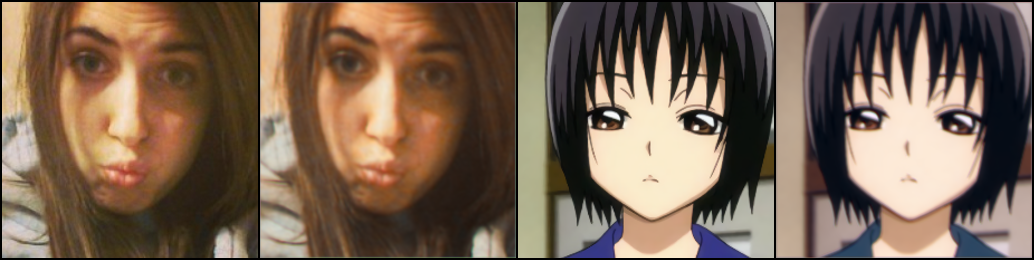

In [8]:
from IPython.display import Image, display
display(Image(filename="images/dataset_n_20250712_1740/100.png"))  # 100은 sample_interval에 따라 생성된 배치 번호


# 모델 3:  AMD 모델 처럼 모델 결과물을 가로 배열로 보이게 하기 

그래픽카드 : nvidia, 에폭수 : 70, 데이터셋 이름: dataset_n3

In [31]:
import torch
from torch.autograd import Variable
from torch.amp import GradScaler
from torch.cuda.amp import autocast # <-- 다시 이 임포트로 변경합니다.

import numpy as np
import datetime
import time
import sys

# ✅ [수정] 학습 epoch 수 변경
n_epochs = 70  

# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

 # --- GPU 정보 출력 ---
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print("CUDA 사용 가능 여부:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("사용 중인 GPU 이름:", torch.cuda.get_device_name(0))
    print("CUDA 디바이스 수:", torch.cuda.device_count())
    print("현재 디바이스 번호:", torch.cuda.current_device())


# cuDNN 최적화
torch.backends.cudnn.benchmark = True

# 모델을 device로 이동
G_AB = G_AB.to(device)
G_BA = G_BA.to(device)
D_A = D_A.to(device)
D_B = D_B.to(device)

# 손실 함수도 device로 이동
criterion_GAN = criterion_GAN.to(device)
criterion_cycle = criterion_cycle.to(device)
criterion_identity = criterion_identity.to(device)

# Mixed Precision Training을 위한 준비
scaler = GradScaler(device="cuda")

# 체크포인트 및 이미지 저장 설정
checkpoint_interval = 10
sample_interval = 100
init_epoch = 0

prev_time = time.time()
for epoch in range(init_epoch, n_epochs):
    for i, batch in enumerate(dataloader):

        # 모델 입력 준비 (device로 이동)
        real_A = batch["A"].to(device)
        real_B = batch["B"].to(device)

        # 진짜/가짜 판별 라벨 생성
        valid = torch.ones((real_A.size(0), *D_A.output_shape), device=device, dtype=torch.float32, requires_grad=False)
        fake = torch.zeros((real_A.size(0), *D_A.output_shape), device=device, dtype=torch.float32, requires_grad=False)

        # 생성자 학습
        G_AB.train()
        G_BA.train()
        optimizer_G.zero_grad()
        
        # --- [필수 정의 끝] --------------------------------------------
        
        

        # Mixed Precision: autocast()를 인자 없이 사용하거나,
        #                   dtype=torch.float16 (또는 torch.bfloat16)과 같이 사용합니다.
        #                   여기서는 가장 기본적인 인자 없는 형태로 변경합니다.
        with autocast(): # <-- 이 부분을 이렇게 변경합니다. (인자 제거)
            # 아이덴티티 손실
            loss_id_A = criterion_identity(G_BA(real_A), real_A)
            loss_id_B = criterion_identity(G_AB(real_B), real_B)
            loss_identity = (loss_id_A + loss_id_B) / 2

            # GAN 손실
            fake_B = G_AB(real_A)
            loss_GAN_AB = criterion_GAN(D_B(fake_B), valid)
            fake_A = G_BA(real_B)
            loss_GAN_BA = criterion_GAN(D_A(fake_A), valid)
            loss_GAN = (loss_GAN_AB + loss_GAN_BA) / 2

            # 사이클 일관성 손실
            recov_A = G_BA(fake_B)
            loss_cycle_A = criterion_cycle(recov_A, real_A)
            recov_B = G_AB(fake_A)
            loss_cycle_B = criterion_cycle(recov_B, real_B)
            loss_cycle = (loss_cycle_A + loss_cycle_B) / 2

            # 전체 생성자 손실
            loss_G = loss_GAN + lambda_cyc * loss_cycle + lambda_id * loss_identity

        scaler.scale(loss_G).backward()
        scaler.step(optimizer_G)
        scaler.update()

        # 판별자 A 학습
        optimizer_D_A.zero_grad()
        with autocast(): # <-- 이 부분도 이렇게 변경합니다. (인자 제거)
            loss_real = criterion_GAN(D_A(real_A), valid)
            fake_A_ = fake_A_buffer.push_and_pop(fake_A)
            loss_fake = criterion_GAN(D_A(fake_A_.detach()), fake)
            loss_D_A = (loss_real + loss_fake) / 2

        scaler.scale(loss_D_A).backward()
        scaler.step(optimizer_D_A)
        scaler.update()

        # 판별자 B 학습
        optimizer_D_B.zero_grad()
        with autocast(): # <-- 이 부분도 이렇게 변경합니다. (인자 제거)
            loss_real = criterion_GAN(D_B(real_B), valid)
            fake_B_ = fake_B_buffer.push_and_pop(fake_B)
            loss_fake = criterion_GAN(D_B(fake_B_.detach()), fake)
            loss_D_B = (loss_real + loss_fake) / 2

        scaler.scale(loss_D_B).backward()
        scaler.step(optimizer_D_B)
        scaler.update()

        # 전체 판별자 손실
        loss_D = (loss_D_A + loss_D_B) / 2

        # 남은 시간 계산
        batches_done = epoch * len(dataloader) + i
        batches_left = n_epochs * len(dataloader) - batches_done
        time_left = datetime.timedelta(seconds=batches_left * (time.time() - prev_time))
        prev_time = time.time()

        # 로그 출력
        sys.stdout.write(
            "\r[Epoch %d/%d] [Batch %d/%d] [D loss: %.4f] [G loss: %.4f, adv: %.4f, cycle: %.4f, identity: %.4f] ETA: %s"
            % (
                epoch,
                n_epochs,
                i,
                len(dataloader),
                loss_D.item(),
                loss_G.item(),
                loss_GAN.item(),
                loss_cycle.item(),
                loss_identity.item(),
                time_left,
            )
        )
        sys.stdout.flush()

        # 이미지 저장
        if batches_done % sample_interval == 0:
            sample_images(batches_done)

    # 학습률 스케줄러 업데이트
    lr_scheduler_G.step()
    lr_scheduler_D_A.step()
    lr_scheduler_D_B.step()

    # 체크포인트 저장
    if checkpoint_interval != -1 and epoch % checkpoint_interval == 0:
        torch.save(G_AB.state_dict(), f"saved_models/{dataset_name}/G_AB_{epoch}.pth")
        torch.save(G_BA.state_dict(), f"saved_models/{dataset_name}/G_BA_{epoch}.pth")
        torch.save(D_A.state_dict(), f"saved_models/{dataset_name}/D_A_{epoch}.pth")
        torch.save(D_B.state_dict(), f"saved_models/{dataset_name}/D_B_{epoch}.pth")

cuda
2.7.1+cu118
11.8
True
CUDA 사용 가능 여부: True
사용 중인 GPU 이름: NVIDIA GeForce RTX 2060
CUDA 디바이스 수: 1
현재 디바이스 번호: 0


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_20600\1214482377.py:75: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # <-- 이 부분을 이렇게 변경합니다. (인자 제거)


[Epoch 0/70] [Batch 0/400] [D loss: 2.1231] [G loss: 12.3421, adv: 3.0613, cycle: 0.6222, identity: 0.6118] ETA: 4:34:33.608017

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_20600\1214482377.py:104: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # <-- 이 부분도 이렇게 변경합니다. (인자 제거)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_20600\1214482377.py:116: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # <-- 이 부분도 이렇게 변경합니다. (인자 제거)


[Epoch 20/70] [Batch 383/400] [D loss: 0.1328] [G loss: 2.8877, adv: 0.4493, cycle: 0.1688, identity: 0.1500] ETA: 1:37:57.269671858074

KeyboardInterrupt: 